A Machine-Learning Analysis of Boston Crime Incident Categories

In [1]:
import pandas as pd

In [7]:
#load the data
df = pd.read_csv("boston_crime_data.csv")

C:\Users\edj44\AppData\Local\Temp\ipykernel_34176\151069605.py:1: DtypeWarning: Columns (0: INCIDENT_NUMBER, 1: REPORTING_AREA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("boston_crime_data.csv")


In [8]:
#The data is too large to load into memory, 
# so we need to use the low_memory option to load it in chunks. 
# This will allow us to load the data without running out of memory,
# but it will also mean that we need to specify the data types for
# each column, so that pandas can properly parse the data.  
df = pd.read_csv(
    "boston_crime_data.csv",
    low_memory=False
)

In [9]:
#Check the first few rows of the data to see what it looks like.
df.head()


,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location
0,232007173,3115,NaN,INVESTIGATE PERSON,B3,,0,2023-01-27 22:44:00+00,2023,1,Friday,22,NaN,FAVRE ST,42.271661,-71.099534,"(42.27166144598919, -71.09953381947697)"
1,232004454,3301,NaN,VERBAL DISPUTE,B2,316,0,2023-01-17 20:21:00+00,2023,1,Tuesday,20,NaN,HAROLD ST,42.312597,-71.092875,"(42.312596725464594, -71.09287521197788)"
2,232006290,3115,NaN,INVESTIGATE PERSON,A1,,0,2023-01-24 00:00:00+00,2023,1,Tuesday,0,NaN,HANOVER ST,42.365700,-71.052892,"(42.36569984586877, -71.052891614826)"
3,232024939,3114,NaN,INVESTIGATE PROPERTY,B3,,0,2023-03-31 17:14:00+00,2023,3,Friday,17,NaN,BLUE HILL AVE,42.292788,-71.088519,"(42.29278842433874, -71.08851887959194)"
4,232006708,423,NaN,ASSAULT - AGGRAVATED,B2,,0,2023-01-26 09:00:00+00,2023,1,Thursday,9,NaN,HUTCHINGS ST,42.310269,-71.089310,"(42.310269344309944, -71.0893099278548)"


In [10]:
#Check the shape of the data to see how many rows and columns it has.
df.shape



(262213, 17)

In [11]:
#print these values separately to make it easier to read.
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

number of rows: 262213
number of columns: 17


In [12]:
#Check the column names to see what features we have to work with.
df.columns

Index(['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OFFENSE_CODE_GROUP',
       'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING',
       'OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'UCR_PART',
       'STREET', 'Lat', 'Long', 'Location'],
      dtype='str')

In [13]:
#Make a copy of the original data frame so that
#we can refer back to it later if we need to.
original_df = df.copy()


In [14]:
#Check the data types of each column to see if there are any issues
# with the data.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 262213 entries, 0 to 262212
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   INCIDENT_NUMBER      262213 non-null  str    
 1   OFFENSE_CODE         262213 non-null  int64  
 2   OFFENSE_CODE_GROUP   0 non-null       float64
 3   OFFENSE_DESCRIPTION  262213 non-null  str    
 4   DISTRICT             261715 non-null  str    
 5   REPORTING_AREA       231570 non-null  str    
 6   SHOOTING             262213 non-null  int64  
 7   OCCURRED_ON_DATE     262213 non-null  str    
 8   YEAR                 262213 non-null  int64  
 9   MONTH                262213 non-null  int64  
 10  DAY_OF_WEEK          262213 non-null  str    
 11  HOUR                 262213 non-null  int64  
 12  UCR_PART             0 non-null       float64
 13  STREET               262213 non-null  str    
 14  Lat                  247135 non-null  float64
 15  Long                 247135 

In [15]:
#The column names are all in uppercase, which is not ideal for working
# with the data.
df.columns = df.columns.str.lower() 

In [16]:
#Check the column names again to see the changes.
print(df.columns.tolist())

['incident_number', 'offense_code', 'offense_code_group', 'offense_description', 'district', 'reporting_area', 'shooting', 'occurred_on_date', 'year', 'month', 'day_of_week', 'hour', 'ucr_part', 'street', 'lat', 'long', 'location']


In [17]:
#Check for missing values in each column to see if there are any issues
# with the data.
df.isnull().sum()

incident_number             0
offense_code                0
offense_code_group     262213
offense_description         0
district                  498
reporting_area          30643
shooting                    0
occurred_on_date            0
year                        0
month                       0
day_of_week                 0
hour                        0
ucr_part               262213
street                      0
lat                     15078
long                    15078
location                15078
dtype: int64

In [18]:
#Print the number of missing values in each column to make it easier
# to read.
missing_values = df.isnull().sum()
print(missing_values)

incident_number             0
offense_code                0
offense_code_group     262213
offense_description         0
district                  498
reporting_area          30643
shooting                    0
occurred_on_date            0
year                        0
month                       0
day_of_week                 0
hour                        0
ucr_part               262213
street                      0
lat                     15078
long                    15078
location                15078
dtype: int64


In [20]:
#print only the columns that have missing values to make it easier
# to read.
print(missing_values[missing_values > 0])

offense_code_group    262213
district                 498
reporting_area         30643
ucr_part              262213
lat                    15078
long                   15078
location               15078
dtype: int64


In [23]:
#The offense_code_group and ucr_part columns have a lot of missing
#  values, so we will drop them from the data frame.
df = df.drop( 
    columns=[
        "offense_code_group",
        "ucr_part"
    ]
)

In [24]:
# Check the shape of the data again to see how many rows and columns
# it has after dropping the columns with a lot of missing values.
df.shape

(262213, 15)

In [27]:
# Check for duplicate rows in the data to see if there are any issues
df.duplicated().sum()
df=df.drop_duplicates()

In [88]:
# remove leading and trailing whitespace from the string columns
# to clean the data.
df["day_of_week"] = df["day_of_week"].str.strip()
df["district"] = df["district"].str.strip()
df["offense_description"] = df["offense_description"].str.strip()
df["street"] = df["street"].str.strip()

In [89]:
# Check the unique values in the day_of_week column
# to see if there are any issues
df["day_of_week"].value_counts()


day_of_week
Friday       40097
Wednesday    38717
Monday       38401
Tuesday      38370
Thursday     38211
Saturday     35778
Sunday       32639
Name: count, dtype: int64

In [90]:
# The offense_description column has some inconsistent capitalization,
# so we will convert all the values to uppercase to make it easier
# to work with.
df["offense_description"] = (
    df["offense_description"].str.upper()
)

In [91]:
# The district and street columns also have some inconsistent capitalization,
# so we will convert all the values to uppercase to make it easier
# to work with.
df["district"] = df["district"].str.upper()
df["street"] = df["street"].str.upper()

In [92]:
# The occurred_on_date column is currently a string, but 
# it should be a datetime
# so that we can work with it more easily. 
# We will convert it to a datetime

df["occurred_on_date"] = pd.to_datetime(
    df["occurred_on_date"],
    errors="coerce"
)

In [93]:
# Check the first few rows of the occurred_on_date column 
# to see the changes.
df["occurred_on_date"].head()

0   2023-01-27 22:44:00+00:00
1   2023-01-17 20:21:00+00:00
2   2023-01-24 00:00:00+00:00
3   2023-03-31 17:14:00+00:00
4   2023-01-26 09:00:00+00:00
Name: occurred_on_date, dtype: datetime64[us, UTC]

In [94]:
# Check the data type of the occurred_on_date column to see the changes.
df["occurred_on_date"].dtype

datetime64[us, UTC]

In [95]:
# Check for missing values in the occurred_on_date column to see if
#  there are any issues
df["occurred_on_date"].isnull().sum()

np.int64(0)

In [96]:
# Print the earliest and latest dates in the occurred_on_date
#  column to see the range of dates in the data.
print(
    "Earliest date:",
    df["occurred_on_date"].min()
)

print(
    "Latest date:", 
    df["occurred_on_date"].max()
)

Earliest date: 2023-01-01 00:00:00+00:00
Latest date: 2026-04-21 02:49:00+00:00


In [97]:
# Create a new column called year that contains the
#  year of the occurred_on_date

df["year"].value_counts().sort_index()


year
2023    78047
2024    79100
2025    81062
2026    24004
Name: count, dtype: int64

In [98]:
# Create a new column called month that contains
#  the month of the occurred_on_date
df["month"].value_counts().sort_index()

month
1     24916
2     23461
3     25438
4     23344
5     21256
6     20086
7     20949
8     21290
9     20940
10    21030
11    19832
12    19671
Name: count, dtype: int64

In [99]:
# Create a new column called hour that contains
#  the hour of the occurred_on_date
df["hour"].value_counts().sort_index()

hour
0     21155
1      6144
2      5390
3      3555
4      2685
5      2898
6      3952
7      7270
8     10790
9     12262
10    13987
11    14209
12    16105
13    13794
14    14184
15    13349
16    16526
17    16898
18    15440
19    12948
20    12010
21    10515
22     9287
23     6860
Name: count, dtype: int64

In [100]:
# Check for invalid values in the month and hour columns to see
#  if there are any issues
print(
    "Invalid months:",
    (~df["month"].between(1, 12)).sum()
)

print(
    "Invalid hours:",
    (~df["hour"].between(0, 23)).sum()
)

Invalid months: 0
Invalid hours: 0


In [101]:
# Check for invalid values in the month column
#  to see if there are any issues
df["month"].between(1, 12)

0         True
1         True
2         True
3         True
4         True
          ... 
262208    True
262209    True
262210    True
262211    True
262212    True
Name: month, Length: 262213, dtype: bool

In [102]:
# Check for invalid values in the district column
df["district"].isnull().sum()

np.int64(0)

In [103]:
# The district column has some missing values, so we will fill them with
#  the value "UNKNOWN" to make it easier to work with.
df["district"] = df["district"].fillna(
    "UNKNOWN"
)

In [104]:

# The reporting_area column also has some missing values, so we will fill
#  them with the value "UNKNOWN" to make it easier to work with.
df["reporting_area"] = (
    df["reporting_area"]
    .fillna("UNKNOWN")
    .astype(str)
    .str.strip()
)

In [105]:
# The street column also has some missing values, so we will fill
# them with the value "UNKNOWN" to make it easier to work with.
df["street"] = df["street"].fillna(
    "UNKNOWN"
)

In [106]:
# Check for missing values in the lat and long columns to
# see if there are any issues
print(
    "Missing latitude:",
    df["lat"].isnull().sum()
)

print(
    "Missing longitude:",
    df["long"].isnull().sum()
)

Missing latitude: 15078
Missing longitude: 15078


In [107]:
# Create a new column called coordinates_missing that contains a 1 if either
# the lat or long columns are missing, and a 0 if both columns have values
df["coordinates_missing"] = (
    df["lat"].isnull()
    | df["long"].isnull()
).astype(int)

In [113]:
# remove the location column since it is redundant with the
#  lat and long columns
if "location" in df.columns:
    df = df.drop(columns=["location"])

df.head()


,incident_number,offense_code,offense_description,district,reporting_area,shooting,occurred_on_date,year,month,day_of_week,hour,street,lat,long,coordinates_missing,is_weekend,time_period,crime_category
0,232007173,3115,INVESTIGATE PERSON,B3,,0,2023-01-27 22:44:00+00:00,2023,1,Friday,22,FAVRE ST,42.271661,-71.099534,0,0,night,other
1,232004454,3301,VERBAL DISPUTE,B2,316,0,2023-01-17 20:21:00+00:00,2023,1,Tuesday,20,HAROLD ST,42.312597,-71.092875,0,0,evening,other
2,232006290,3115,INVESTIGATE PERSON,A1,,0,2023-01-24 00:00:00+00:00,2023,1,Tuesday,0,HANOVER ST,42.365700,-71.052892,0,0,late_night,other
3,232024939,3114,INVESTIGATE PROPERTY,B3,,0,2023-03-31 17:14:00+00:00,2023,3,Friday,17,BLUE HILL AVE,42.292788,-71.088519,0,0,afternoon,other
4,232006708,423,ASSAULT - AGGRAVATED,B2,,0,2023-01-26 09:00:00+00:00,2023,1,Thursday,9,HUTCHINGS ST,42.310269,-71.089310,0,0,morning,violent


In [ ]:
#inspect values in the shooting column to see if there are any issues
df["shooting"].value_counts(
    dropna=False
)

shooting
0    260448
1      1765
Name: count, dtype: int64

In [ ]:
#convert the columns to numeric
df["shooting"] = pd.to_numeric(
    df["shooting"],
    errors="coerce"
)

In [ ]:
# Check for missing values in the shooting column to see if
# there are any issues
df["shooting"] = df["shooting"].astype(int)

In [ ]:
# Create a new column called is_weekend that contains a 1
# if the day_of_week is Saturday or Sunday, and a 0 otherwise
df["is_weekend"] = (
    df["day_of_week"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

In [ ]:
# Check the day_of_week and is_weekend rows of the data to see the changes.
df[
    ["day_of_week", "is_weekend"]
].head(10)

,day_of_week,is_weekend
0,Friday,0
1,Tuesday,0
2,Tuesday,0
3,Friday,0
4,Thursday,0
5,Sunday,1
6,Tuesday,0
7,Thursday,0
8,Tuesday,0
9,Wednesday,0


In [ ]:
# Create a function called get_time_period that takes an hour as input and returns a string
def get_time_period(hour):
    if hour < 6:
        return "late_night"

    elif hour < 12:
        return "morning"

    elif hour < 18:
        return "afternoon"

    elif hour < 22:
        return "evening"

    else:
        return "night"

In [ ]:
# Create a new column called time_period that contains
# the time period of the day
df["time_period"] = df["hour"].apply(
    get_time_period
)

In [ ]:
# Check the hour and time_period rows of the data to see the changes.
df[
    ["hour", "time_period"]
].head(10)

,hour,time_period
0,22,night
1,20,evening
2,0,late_night
3,17,afternoon
4,9,morning
5,14,afternoon
6,11,morning
7,12,afternoon
8,12,afternoon
9,18,evening


In [ ]:
# Create two lists of words, one for violent crimes and one for property
# crimes, to help us categorize the offense descriptions.
violent_words = [
    "ASSAULT",
    "ROBBERY",
    "HOMICIDE",
    "MANSLAUGHTER",
    "RAPE",
    "SEXUAL",
    "KIDNAPPING"
]

property_words = [
    "LARCENY",
    "BURGLARY",
    "THEFT",
    "VANDALISM",
    "ARSON",
    "STOLEN",
    "PROPERTY DAMAGE"
]

In [ ]:
# Create a function called create_crime_category that takes an
# offense description as input and returns a crime category based on
# the presence of certain words in the description.

def create_crime_category(description):

    for word in violent_words:
        if word in description:
            return "violent"

    for word in property_words:
        if word in description:
            return "property"

    return "other"

In [ ]:
# Create a new column called crime_category that contains the crime category
df["crime_category"] = (
    df["offense_description"]
    .apply(create_crime_category)
)

In [ ]:
# Check the offense_description and crime_category rows of the data to
# see the changes.
df["crime_category"].value_counts()

crime_category
other       171188
property     72928
violent      18097
Name: count, dtype: int64

In [ ]:
# Check the percentage of each crime category to see the distribution of
# crime types in the data.
df["crime_category"].value_counts(
    normalize=True
) * 100

crime_category
other       65.285855
property    27.812504
violent      6.901641
Name: proportion, dtype: float64

In [ ]:
# Check the most common offense descriptions for violent crimes to see
# what types of violent crimes are most common in the data.
df[
    df["crime_category"] == "violent"
][
    "offense_description"
].value_counts().head(20)

offense_description
ASSAULT - SIMPLE                              10488
ASSAULT - AGGRAVATED                           5157
ROBBERY                                        2330
MURDER, NON-NEGLIGENT MANSLAUGHTER               81
KIDNAPPING/CUSTODIAL KIDNAPPING/ ABDUCTION       32
MANSLAUGHTER - VEHICLE - NEGLIGENCE               6
MURDER, NON-NEGLIGIENT MANSLAUGHTER               1
JUSTIFIABLE HOMICIDE                              1
MANSLAUGHTER - NEGLIGENCE                         1
Name: count, dtype: int64

In [114]:
# Check the most common offense descriptions for property crimes to see
# what types of property crimes are most common in the data.
df[df["crime_category"] == "property"]["offense_description"].value_counts().head(20)

offense_description
M/V - LEAVING SCENE - PROPERTY DAMAGE                                         15538
LARCENY SHOPLIFTING                                                           12300
VANDALISM                                                                      9029
LARCENY THEFT FROM BUILDING                                                    6531
LARCENY THEFT FROM MV - NON-ACCESSORY                                          6037
M/V ACCIDENT - PROPERTY DAMAGE                                                 5994
LARCENY ALL OTHERS                                                             5610
AUTO THEFT                                                                     2952
BURGLARY - RESIDENTIAL                                                         1948
LARCENY THEFT OF BICYCLE                                                       1876
BURGLARY - COMMERICAL                                                          1198
AUTO THEFT - MOTORCYCLE / SCOOTER                       

In [ ]:
df[
    df["crime_category"] == "other"
][
    "offense_description"
].value_counts().head(20)

offense_description
INVESTIGATE PERSON                              26299
SICK ASSIST                                     24030
TOWED MOTOR VEHICLE                             11831
INVESTIGATE PROPERTY                            11387
PROPERTY - LOST/ MISSING                         9060
DRUGS - POSSESSION/ SALE/ MANUFACTURING/ USE     7253
VERBAL DISPUTE                                   6339
THREATS TO DO BODILY HARM                        5922
M/V ACCIDENT - OTHER                             5534
MISSING PERSON - LOCATED                         4006
VAL - VIOLATION OF AUTO LAW                      4000
HARASSMENT/ CRIMINAL HARASSMENT                  3931
SICK/INJURED/MEDICAL - PERSON                    3416
FRAUD - FALSE PRETENSE / SCHEME                  3327
PROPERTY - FOUND                                 3264
M/V ACCIDENT - PERSONAL INJURY                   3076
SICK ASSIST - DRUG RELATED ILLNESS               2559
M/V ACCIDENT - INVOLVING PEDESTRIAN - INJURY     1900
SUDDEN D

In [ ]:
# Save the cleaned data to a new CSV file so that we can use it for analysis.
df.to_csv(
    "boston_crime_cleaned.csv",
    index=False
)

In [ ]:
# Create a list of the features that we want to use for analysis.
features = [
    "district",
    "reporting_area",
    "month",
    "day_of_week",
    "hour",
    "is_weekend",
    "time_period"
]

In [ ]:
# Create a new data frame called X that contains 
# the features that we want to use for analysis.
X = df[features]

In [ ]:
# Create a new data frame called y that contains the target variable, which is
# the crime category.
y = df["crime_category"]

In [ ]:
# The code above prepares the dataset for machine learning 
# by selecting relevant features and the target variable.

#In machine learning:

#X contains the information used to make predictions.
#y contains the answer we want the model to predict.

#We exclude:

#offense_code
#offense_description
#incident_number
#shooting

#The offense code and description directly reveal the target.
#Including them would create data leakage.

In [ ]:
!pip install -q scikit-learn
from sklearn.model_selection import train_test_split

In [ ]:
#The data is divided into:

#80% training data
#20% test data

#The training data teaches the model.

#The test data evaluates the model on records it has not seen.

#random_state=42 makes the split repeatable.

#stratify=y keeps similar class percentages in the training
#and test sets.



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#Print the number of rows in the training and test sets to see the split.
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 209770
Testing rows: 52443


In [ ]:
#create a baseline model before we build a logistic regression model 
#so that we have a point of comparison to evaluate our logistic regression model against.
from sklearn.dummy import DummyClassifier

In [ ]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train,
    y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.65,0.28,0.07]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](3,)","['other','property','violent']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](7,)","['district','reporting_area','month',...,'hour','is_weekend','time_period']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,7
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [115]:
baseline_predictions = (
    baseline_model.predict(X_test)
)

In [116]:
#What does this model do?

#It predicts the most common category for every incident.

#It does not actually learn useful patterns.

#Our real model should perform better than this baseline.


from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline accuracy:",
    baseline_accuracy
)

Baseline accuracy: 0.6528612016856397


In [117]:
# perpare the data for logistic regression 

numeric_features = [ 
    "month", 
    "hour", 
    "is_weekend"
]

In [118]:
categorical_features = [ 
    "district", 
    "reporting_area", 
    "day_of_week", 
    "time_period"
]

In [120]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# The ColumnTransformer applies different transformations to different
# columns of the data.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categories",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numbers",
            "passthrough",
            numeric_features
        )
    ]
)

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [125]:
# The Pipeline chains together the preprocessing and model steps,
# so that we can fit the model to the training data and make predictions
# on the test data in one step.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numbers",
            "passthrough",
            numeric_features
        )
    ]
)


In [ ]:
#What is a pipeline?

#A pipeline performs multiple steps in the correct order.

#In this project, it:

#Converts the categorical variables into numbers.
#Passes through the numeric variables.
#Trains logistic regression.

#max_iter=1000 gives the model enough attempts to finish training.

#class_weight="balanced" gives additional importance to smaller classes.

In [126]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [128]:
#What does fit() mean?

#fit() teaches the model.

#The model examines relationships between:

#the features in X_train,
#and the correct categories in y_train.

logistic_model.fit(
    X_train,
    y_train
)

c:\Users\edj44\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['other','property','violent']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['district','reporting_area','month',...,'hour','is_weekend','time_period']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categories', ...), ('numbers', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [129]:
predictions = logistic_model.predict(
    X_test
)

In [130]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = predictions

results.head(10)

,district,reporting_area,month,day_of_week,hour,is_weekend,time_period,actual,predicted
132381,B2,182,8,Monday,0,0,late_night,other,other
39247,E5,691,2,Monday,0,0,late_night,other,other
55869,D4,149,9,Friday,13,0,afternoon,other,property
185206,B3,UNKNOWN,4,Tuesday,19,0,evening,other,other
151368,C11,351,2,Sunday,19,1,evening,other,violent
189705,C11,351,11,Saturday,13,1,afternoon,other,violent
24109,B2,593,9,Wednesday,14,0,afternoon,property,property
144481,B3,466,5,Sunday,0,1,late_night,other,other
74099,E18,516,5,Thursday,21,0,evening,other,other
86868,D4,167,12,Friday,0,0,late_night,property,property


In [132]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [133]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.4167381728734054


In [134]:
balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        predictions
    )
)

print(
    "Balanced accuracy:",
    balanced_accuracy
)

Balanced accuracy: 0.45745969558940835


Important metrics
Precision: When the model predicts a category, how often is it correct?
Recall: Of all actual incidents in a category, how many did the model identify?
F1 score: A balance between precision and recall.
Support: The number of actual records in each category.

In [135]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       other       0.75      0.37      0.50     34238
    property       0.41      0.50      0.45     14586
     violent       0.10      0.50      0.17      3619

    accuracy                           0.42     52443
   macro avg       0.42      0.46      0.37     52443
weighted avg       0.61      0.42      0.46     52443



Important metrics
Precision: When the model predicts a category, how often is it correct?
Recall: Of all actual incidents in a category, how many did the model identify?
F1 score: A balance between precision and recall.
Support: The number of actual records in each category.

In [139]:
!pip install -q matplotlib
import matplotlib.pyplot as plt


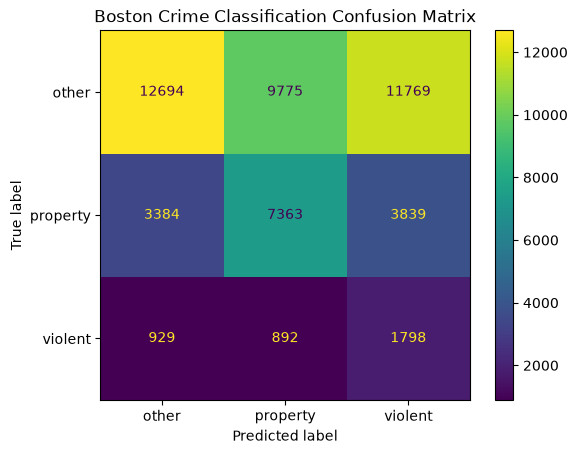

In [141]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title(
    "Boston Crime Classification Confusion Matrix"
)

plt.show()

The confusion matrix shows:

correct classifications,
incorrect classifications,
and which classes are frequently confused.

A normalized version is often easier to compare:

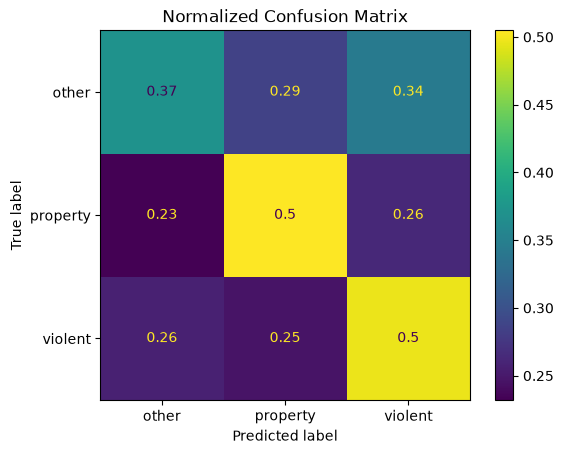

In [142]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    normalize="true"
)

plt.title(
    "Normalized Confusion Matrix"
)

plt.show()